In [1]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors

from cluster import *


# get working directory
os.chdir("d:\\MasterThesis")
os.getcwd()

'd:\\MasterThesis'

In [2]:
# Preprocess
from preprocess_bxr import *

fileDirectory_dissorg = "data\\test_data\\"
fileName_dissorg = 'testdata_results.bxr' # name of BXR file 

fileDirectory_excit = "data\\excit_data\\"
fileName_excit = '20240627-iPCS-1806-div35-iNeurons_00.bxr' # name of BXR file 

wf_dissorg = extract_waveforms_from_bxr(fileDirectory_dissorg, fileName_dissorg)
wf_excit = extract_waveforms_from_bxr(fileDirectory_excit, fileName_excit)

wf_dissorg_preprocessed = preprocess_waveforms(
    wf_dissorg,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_dissorg_SMOOTH.csv")

wf_excit_preprocessed = preprocess_waveforms(
    wf_excit,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_excit_SMOOTH.csv")

Saved 87 mean waveforms to: mean_waveforms_preprocessed_dissorg_SMOOTH.csv
Saved 807 mean waveforms to: mean_waveforms_preprocessed_excit_SMOOTH.csv


### Unsmoothed, unnormalised

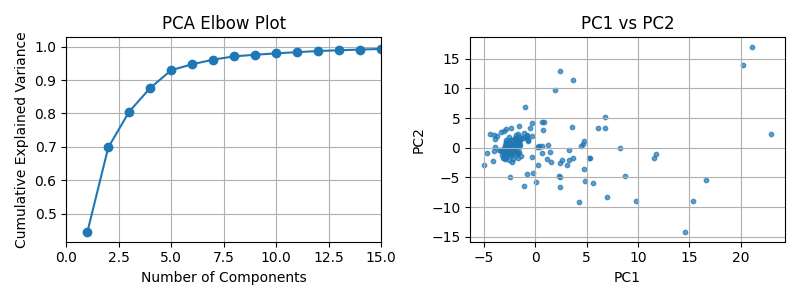

Components that explain 90% of variance: 5


In [3]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_Test.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_Test.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


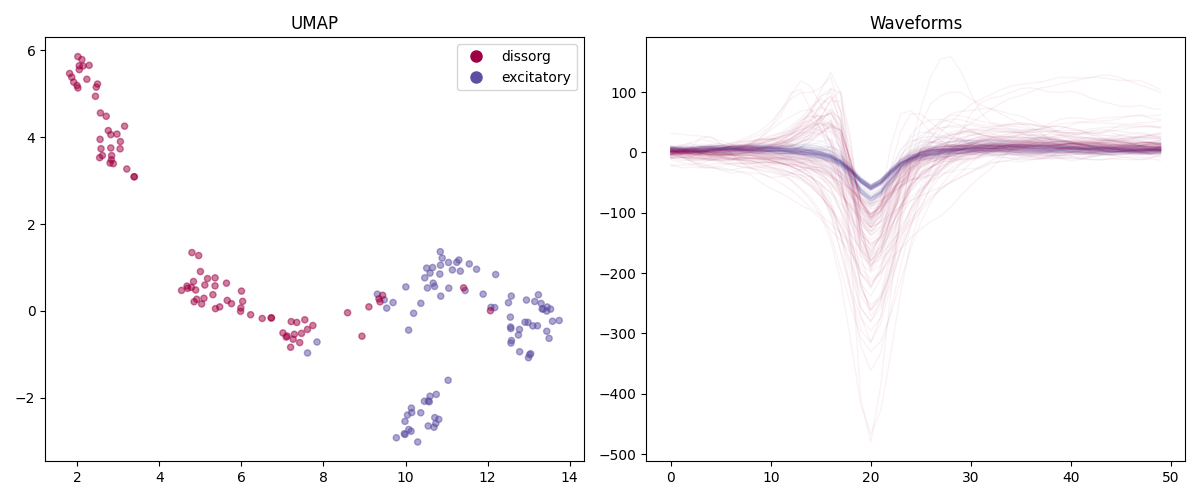

In [4]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

### Smoothed and Normalised

gf, sigma = 2

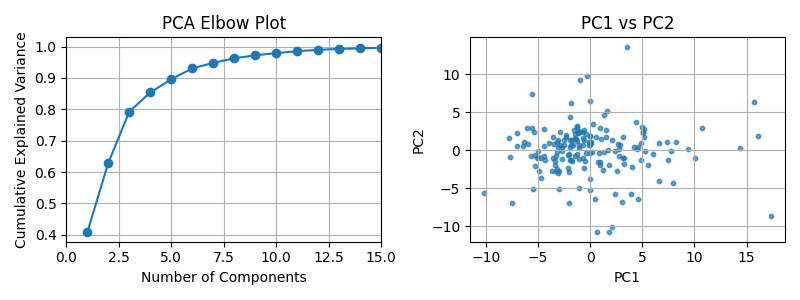

Components that explain 90% of variance: 6


In [5]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_SMOOTH.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_SMOOTH.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


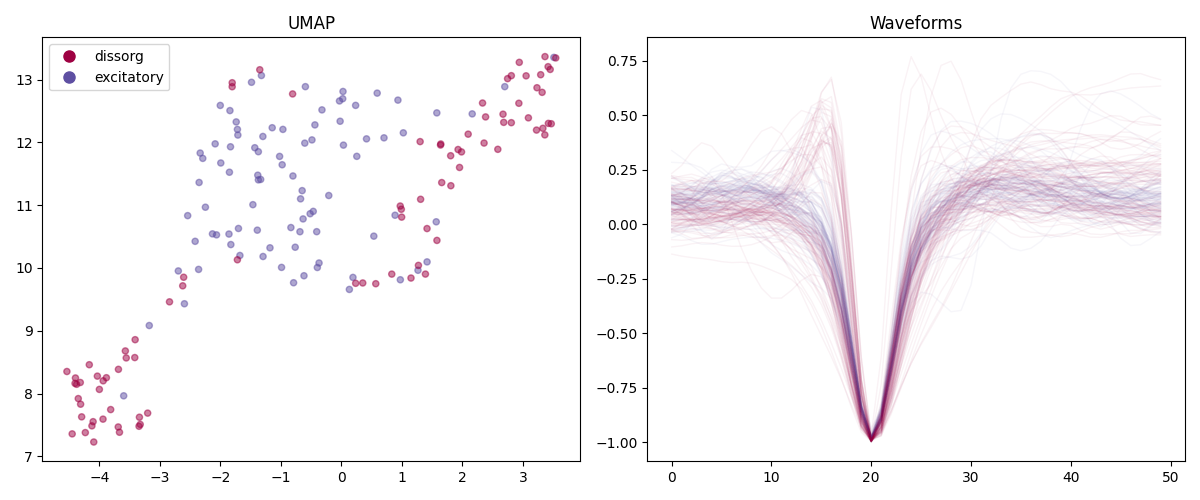

In [6]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

Okay, so, it seems like I'm preprocessing all the single waves, and only at the end am I taking the mean. Maybe it's worth trying to take the mean after the filtering has happened. Will that make a difference?

Okay let's test this, functions have been updated

In [7]:
# New preprocessing, taking the mean first

from preprocess_bxr import *

fileDirectory_dissorg = "data\\test_data\\"
fileName_dissorg = 'testdata_results.bxr' # name of BXR file 

fileDirectory_excit = "data\\excit_data\\"
fileName_excit = '20240627-iPCS-1806-div35-iNeurons_00.bxr' # name of BXR file 

wf_dissorg = extract_waveforms_from_bxr(fileDirectory_dissorg, fileName_dissorg)
wf_excit = extract_waveforms_from_bxr(fileDirectory_excit, fileName_excit)

wf_dissorg_preprocessed = preprocess_waveforms_meanfirst(
    wf_dissorg,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1.5},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_dissorg_NEWPREP2.csv")

wf_excit_preprocessed = preprocess_waveforms_meanfirst(
    wf_excit,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1.5},
    min_waveforms=100,  
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_excit_NEWPREP2.csv")

Saved 87 rows to: mean_waveforms_preprocessed_dissorg_NEWPREP2.csv
Saved 193 rows to: mean_waveforms_preprocessed_excit_NEWPREP2.csv


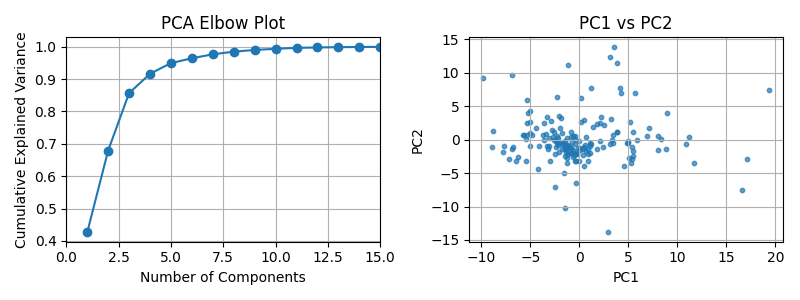

Components that explain 90% of variance: 4


In [8]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_NEWPREP2.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_NEWPREP2.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


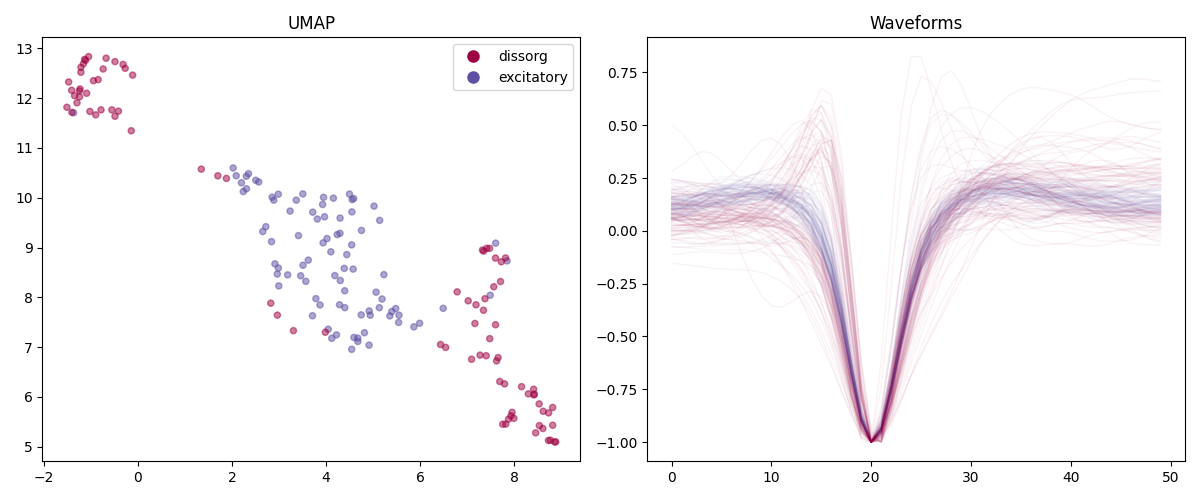

In [9]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

Okay I guess this is still quite messy. Next thing.

-----

## Try using the brw extractions instead

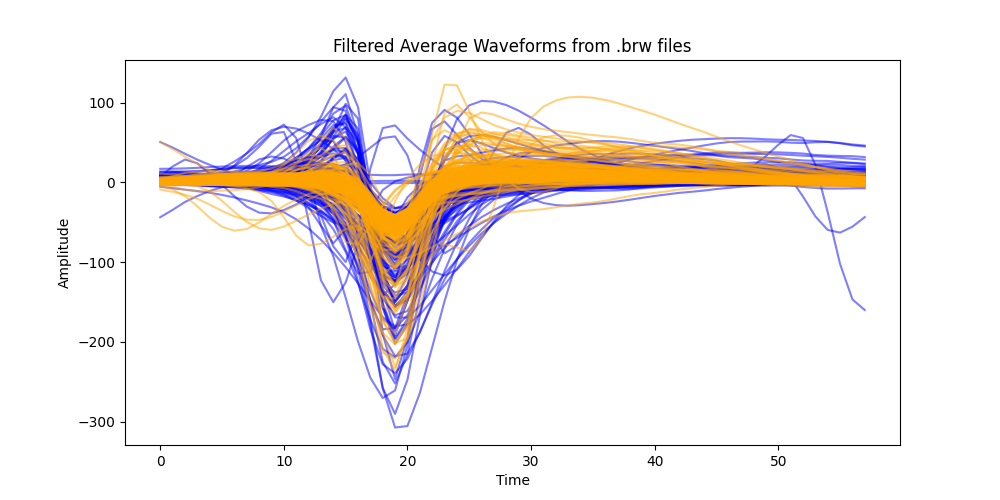

In [10]:
# See how the filtered average waves look at the moment
data_path_dissorg = "d:\\MasterThesis\\analyzer_output\\test_data\\average_waveforms_filtered3.csv"
data_path_excit = "d:\\MasterThesis\\analyzer_output\\excit_data\\average_waveforms_excit_filtered3.csv"

wf_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
wf_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

# Plot the waveforms
plt.figure(figsize=(10, 5))
plt.plot(wf_dissorg.T, color='blue', alpha=0.5, label='Dissorg')
plt.plot(wf_excit.T, color='orange', alpha=0.5, label='Excitatory')
plt.title('Filtered Average Waveforms from .brw files')
plt.xlabel('Time')
#plt.xlim(15,25)
plt.ylabel('Amplitude')
plt.show()

### NEW FILTERING


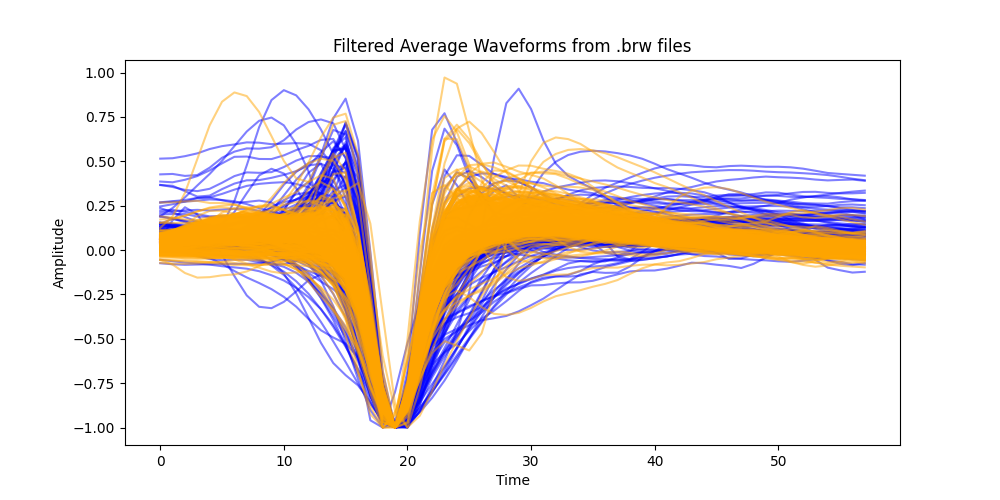

In [11]:
# NEW FILTERING

data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit.csv"

wf_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
wf_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

# Plot the waveforms
plt.figure(figsize=(10, 5))
plt.plot(wf_dissorg.T[:,:], color='blue', alpha=0.5, label='Dissorg')
plt.plot(wf_excit.T[:,:], color='orange', alpha=0.5, label='Excitatory')
plt.title('Filtered Average Waveforms from .brw files')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

Could delete any other waves containing other negative prominent peaks?

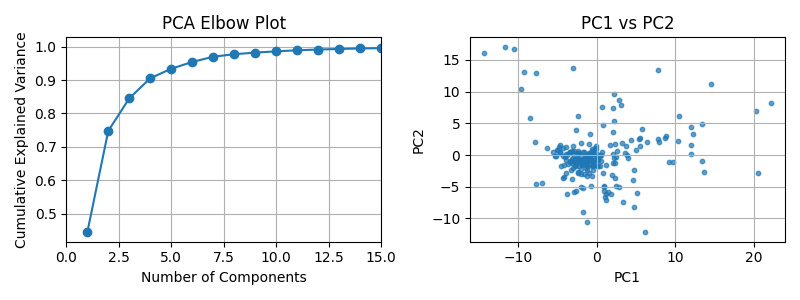

Components that explain 90% of variance: 4


In [12]:
data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


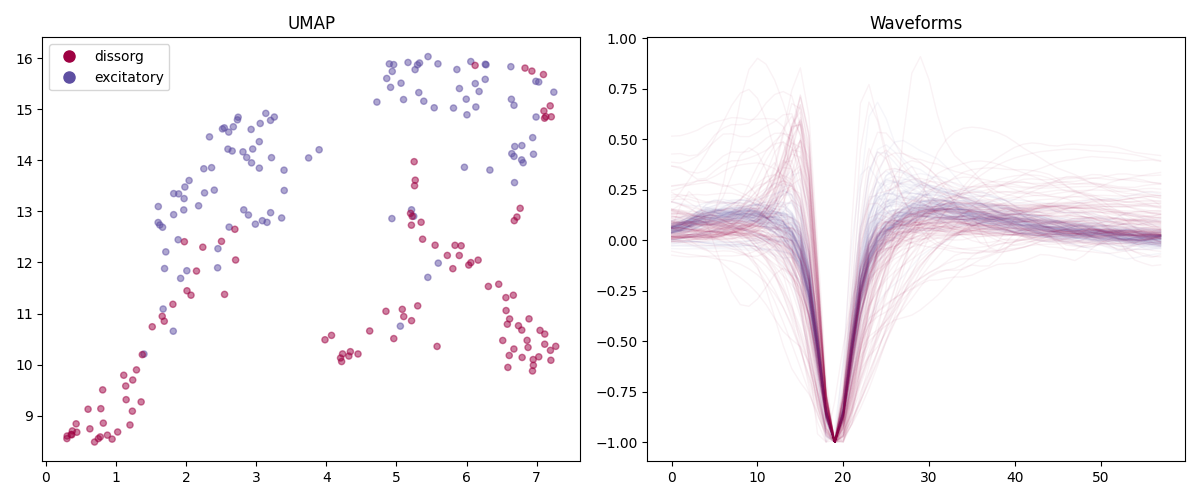

In [13]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

Pass `objective` as keyword args.
ntree_limit is deprecated, use `iteration_range` or model slicing instead.


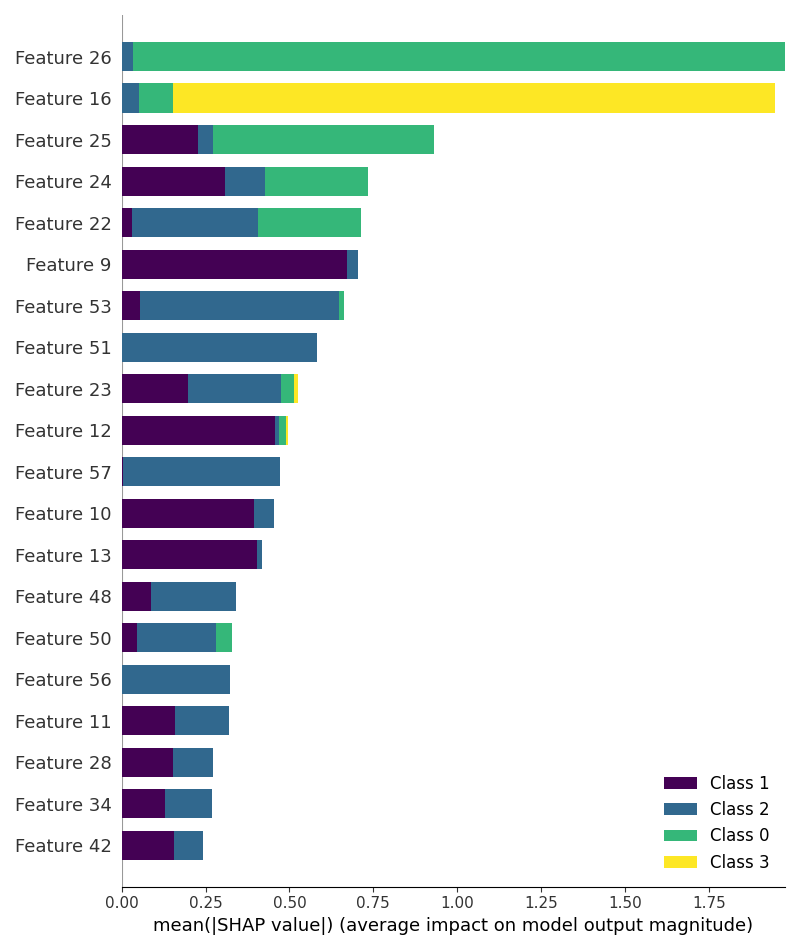

In [16]:
import shap 
import xgboost as xgb 
from wavemap_paper.helper_functions import train_gridsearch_classifier, plot_confusion_matrix 
umap_model, conf_mat = train_gridsearch_classifier(umap_df)
import matplotlib as mpl 

xgbModel = xgb.XGBClassifier(umap_model.best_params_) 
xgbModel.fit(umap_df['waveform'].tolist(),umap_df['cluster_id'].tolist()) 
explainer = shap.TreeExplainer(xgbModel)

plt.close('all')
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0,1,len(set(clustering_solution))))
umap_cmap = mpl.colors.ListedColormap(colors, name='umap_cmap') 
shap_values = explainer.shap_values(umap_df['waveform'].tolist()) 
shap.summary_plot(shap_values, color = umap_cmap)

In [18]:
print(shap_values)

[array([[-0.01422884,  0.        ,  0.01216452, ...,  0.        ,
         0.        ,  0.        ],
       [-0.04639207,  0.        , -0.00741844, ...,  0.        ,
         0.        ,  0.        ],
       [-0.04639207,  0.        ,  0.01216452, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.06074323,  0.        , -0.00741844, ...,  0.        ,
         0.        ,  0.        ],
       [-0.04639207,  0.        ,  0.00203854, ...,  0.        ,
         0.        ,  0.        ],
       [-0.02732675,  0.        , -0.03509154, ...,  0.        ,
         0.        ,  0.        ]], dtype=float32), array([[ 0.08586743,  0.0012004 ,  0.06215147, ..., -0.03606365,
         0.        , -0.00080338],
       [-0.05187377,  0.00486992, -0.05603674, ..., -0.01016059,
         0.        , -0.00139594],
       [ 0.06403497, -0.03997002,  0.06187908, ..., -0.02209971,
         0.        , -0.00139594],
       ...,
       [-0.08251017,  0.0020208 , -0.05798818, ..., -0.006